=== XGBOOST ENHANCED TRAINING ===
Data shape: (101766, 71)
Target distribution:
readmitted
0    90409
1    11357
Name: count, dtype: int64
Training set: (81412, 70), Test set: (20354, 70)
Training Enhanced XGBoost...
Fitting 5 folds for each of 48 candidates, totalling 240 fits

XGBOOST - TEST SET PERFORMANCE
              precision    recall  f1-score   support

           0       0.93      0.63      0.75     18083
           1       0.18      0.63      0.28      2271

    accuracy                           0.63     20354
   macro avg       0.55      0.63      0.51     20354
weighted avg       0.85      0.63      0.70     20354

AUC-ROC Score: 0.6787

Confusion Matrix:
True Negatives: 11456, False Positives: 6627
False Negatives: 848, True Positives: 1423

Additional Metrics:
Accuracy: 0.6328
Precision: 0.1768
Recall: 0.6266
F1-Score: 0.2757

THRESHOLD OPTIMIZATION ANALYSIS
Threshold Analysis:
Threshold 0.1: Precision=0.113, Recall=1.000, F1-Score=0.203
Threshold 0.2: Precision=0.115,

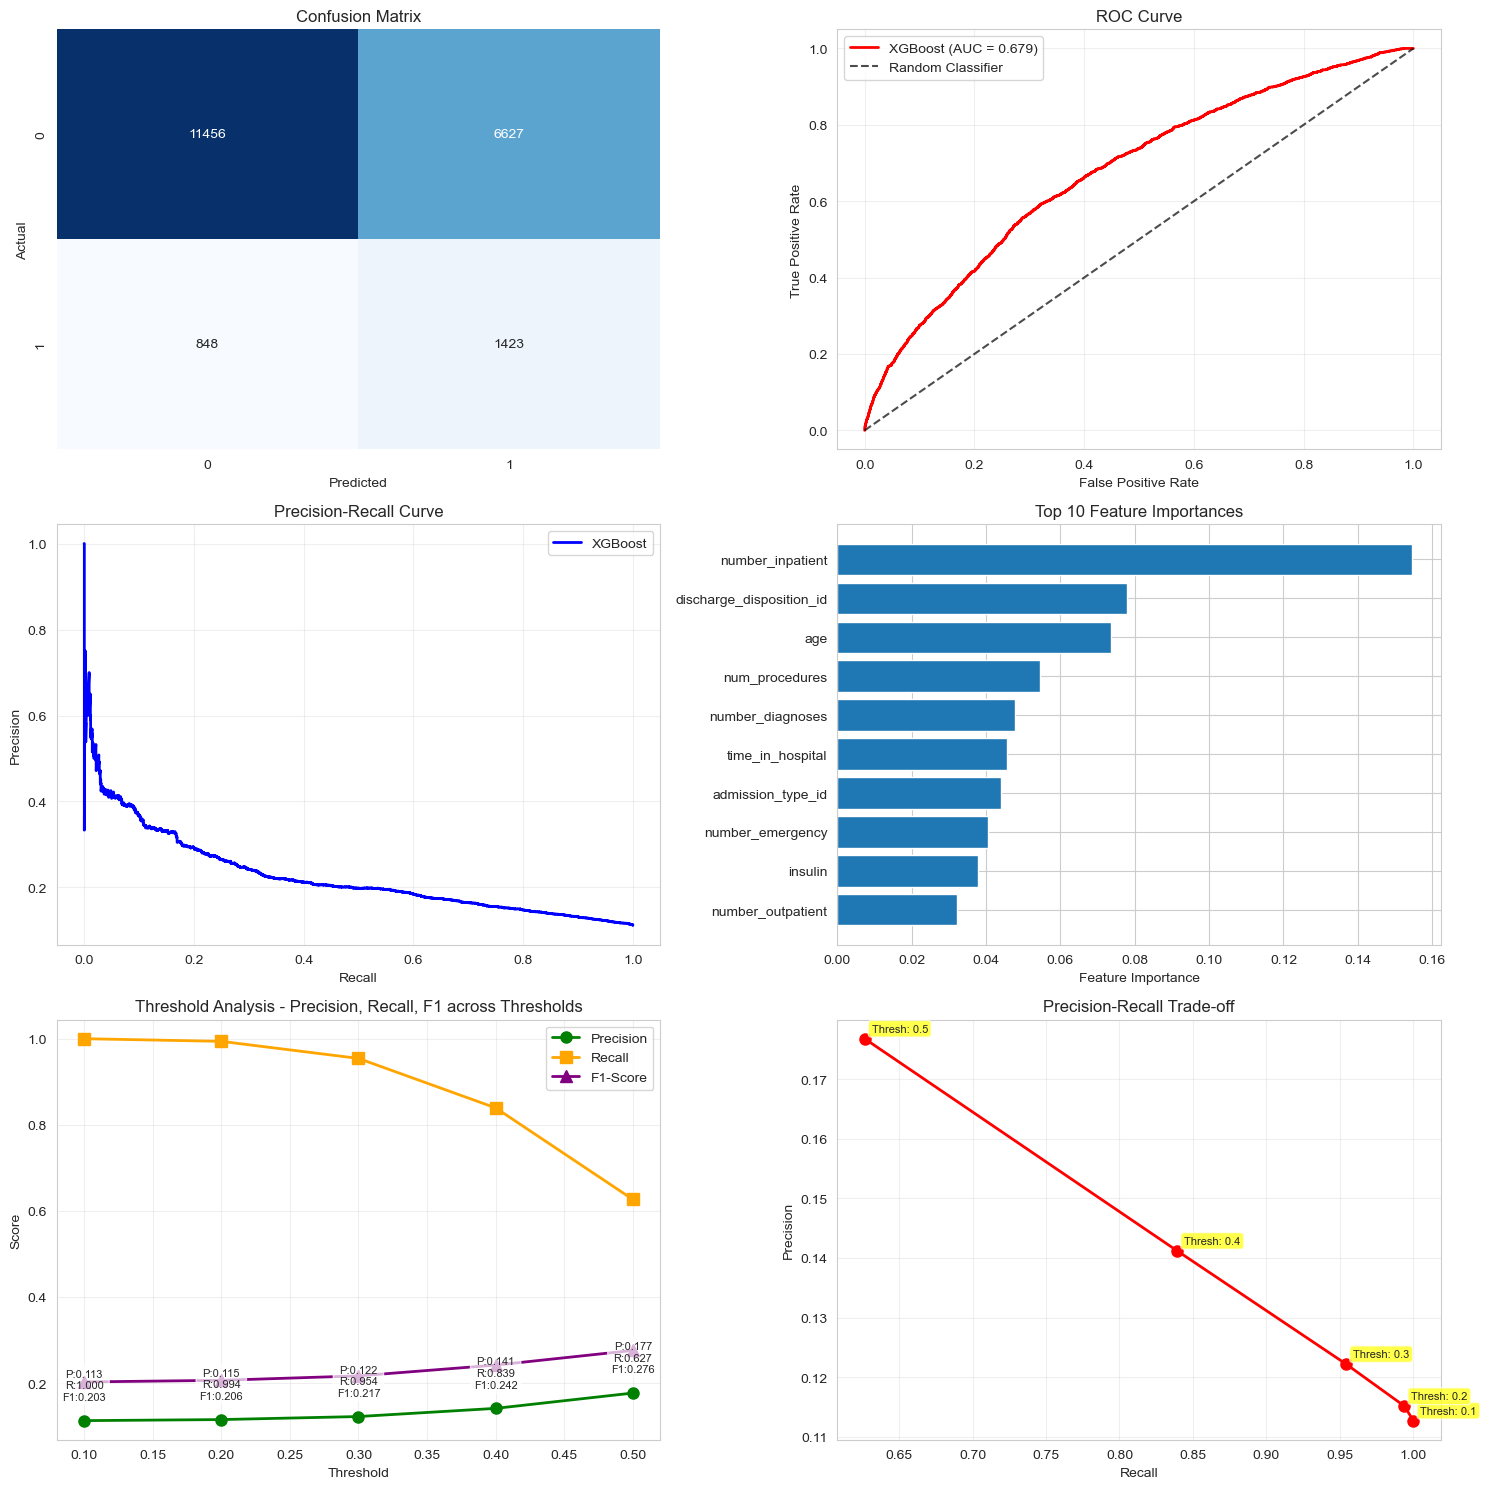


DETAILED PERFORMANCE METRICS
           Metric  Score
          AUC-ROC 0.6787
         Accuracy 0.6328
Balanced Accuracy 0.6301
        Precision 0.1768
           Recall 0.6266
         F1-Score 0.2757
              MCC 0.1675

XGBoost training and evaluation completed!


In [ ]:
# Import essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, accuracy_score, f1_score, precision_score, recall_score, make_scorer, classification_report
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import warnings
warnings.filterwarnings('ignore')

print("=== XGBOOST ENHANCED TRAINING ===")

# Set up visual settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Load data
file_path = r"C:\Users\dinne\Diabetic-Readmissions-\Data\Processed\cleaned_diabetic_data.csv"
df = pd.read_csv(file_path)
print(f"Data shape: {df.shape}")
print(f"Target distribution:\n{df['readmitted'].value_counts()}")

# Split data
X = df.drop('readmitted', axis=1)
y = df['readmitted']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")

# Enhanced custom scoring
custom_scorers = {
    'f1': 'f1',
    'precision': make_scorer(precision_score, pos_label=1),
    'recall': make_scorer(recall_score, pos_label=1),
    'roc_auc': 'roc_auc',
    'balanced_accuracy': 'balanced_accuracy'
}

# Define cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Enhanced XGBoost Pipeline
xgb_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42, sampling_strategy=0.3)),
    ('classifier', XGBClassifier(
        random_state=42, 
        eval_metric='logloss',
        use_label_encoder=False
    ))
])

# Enhanced parameter grid
xgb_param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [3, 4, 5],
    'classifier__learning_rate': [0.05, 0.1],
    'classifier__min_child_weight': [1, 3],
    'classifier__subsample': [0.8, 0.9],
    'classifier__scale_pos_weight': [len(y_train[y_train==0])/len(y_train[y_train==1])]
}

print("Training Enhanced XGBoost...")
xgb_grid = GridSearchCV(
    xgb_pipeline, 
    xgb_param_grid, 
    cv=cv, 
    scoring=custom_scorers,
    refit='f1',
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train, y_train)
xgb_model = xgb_grid.best_estimator_
#MODEL EVALUATIONS
# Get predictions and probabilities
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Calculate metrics
auc_score = roc_auc_score(y_test, y_pred_proba_xgb)
accuracy = accuracy_score(y_test, y_pred_xgb)
precision = precision_score(y_test, y_pred_xgb)
recall = recall_score(y_test, y_pred_xgb)
f1 = f1_score(y_test, y_pred_xgb)

# Get confusion matrix values
cm = confusion_matrix(y_test, y_pred_xgb)
tn, fp, fn, tp = cm.ravel()

# PRINT RESULTS IN REQUESTED FORMAT
print("\n" + "="*50)
print("XGBOOST - TEST SET PERFORMANCE")
print("="*50)

# Classification report
print(classification_report(y_test, y_pred_xgb, target_names=['0', '1']))

print(f"AUC-ROC Score: {auc_score:.4f}\n")

# Confusion Matrix details
print("Confusion Matrix:")
print(f"True Negatives: {tn}, False Positives: {fp}")
print(f"False Negatives: {fn}, True Positives: {tp}\n")

# Additional Metrics
print("Additional Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# THRESHOLD ANALYSIS DATA
print("\n" + "="*50)
print("THRESHOLD OPTIMIZATION ANALYSIS")
print("="*50)

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]
precisions = []
recalls = []
f1_scores = []

print("Threshold Analysis:")
for threshold in thresholds:
    y_pred_temp = (y_pred_proba_xgb >= threshold).astype(int)
    prec = precision_score(y_test, y_pred_temp)
    rec = recall_score(y_test, y_pred_temp)
    f1_val = f1_score(y_test, y_pred_temp)
    
    precisions.append(prec)
    recalls.append(rec)
    f1_scores.append(f1_val)
    
    print(f"Threshold {threshold}: Precision={prec:.3f}, Recall={rec:.3f}, F1-Score={f1_val:.3f}")

# VISUALIZATIONS
print("\n" + "="*50)
print("VISUALIZATIONS")
print("="*50)

# Create 3x2 visualization grid
fig, axes = plt.subplots(3, 2, figsize=(15, 15))

# 1. Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0], cbar=False)
axes[0,0].set_title('Confusion Matrix')
axes[0,0].set_xlabel('Predicted')
axes[0,0].set_ylabel('Actual')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_xgb)
axes[0,1].plot(fpr, tpr, label=f'XGBoost (AUC = {auc_score:.3f})', linewidth=2, color='red')
axes[0,1].plot([0, 1], [0, 1], 'k--', label='Random Classifier', alpha=0.7)
axes[0,1].set_xlabel('False Positive Rate')
axes[0,1].set_ylabel('True Positive Rate')
axes[0,1].set_title('ROC Curve')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# 3. Precision-Recall Curve
from sklearn.metrics import precision_recall_curve
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_pred_proba_xgb)
axes[1,0].plot(recall_vals, precision_vals, label='XGBoost', linewidth=2, color='blue')
axes[1,0].set_xlabel('Recall')
axes[1,0].set_ylabel('Precision')
axes[1,0].set_title('Precision-Recall Curve')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# 4. Feature Importance
try:
    feature_importances = xgb_model.named_steps['classifier'].feature_importances_
    feature_names = X.columns
    indices = np.argsort(feature_importances)[::-1][:10]  # Top 10 features
    
    axes[1,1].barh(range(len(indices)), feature_importances[indices][::-1])
    axes[1,1].set_yticks(range(len(indices)))
    axes[1,1].set_yticklabels([feature_names[i] for i in indices][::-1])
    axes[1,1].set_xlabel('Feature Importance')
    axes[1,1].set_title('Top 10 Feature Importances')
except Exception as e:
    axes[1,1].text(0.5, 0.5, 'Feature Importance\nNot Available', 
             ha='center', va='center', transform=axes[1,1].transAxes)
    axes[1,1].set_title('Feature Importance')

# 5. THRESHOLD ANALYSIS GRAPH
axes[2,0].plot(thresholds, precisions, 'o-', label='Precision', linewidth=2, markersize=8, color='green')
axes[2,0].plot(thresholds, recalls, 's-', label='Recall', linewidth=2, markersize=8, color='orange')
axes[2,0].plot(thresholds, f1_scores, '^-', label='F1-Score', linewidth=2, markersize=8, color='purple')
axes[2,0].set_xlabel('Threshold')
axes[2,0].set_ylabel('Score')
axes[2,0].set_title('Threshold Analysis - Precision, Recall, F1 across Thresholds')
axes[2,0].legend()
axes[2,0].grid(True, alpha=0.3)

# Add value annotations on the points
for i, threshold in enumerate(thresholds):
    axes[2,0].annotate(f'P:{precisions[i]:.3f}\nR:{recalls[i]:.3f}\nF1:{f1_scores[i]:.3f}', 
                      (threshold, precisions[i]), 
                      textcoords="offset points", 
                      xytext=(0,15), 
                      ha='center', 
                      fontsize=8,
                      bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))

# 6. PRECISION-RECALL TRADE-OFF
axes[2,1].plot(recalls, precisions, 'o-', linewidth=2, markersize=8, color='red')
axes[2,1].set_xlabel('Recall')
axes[2,1].set_ylabel('Precision')
axes[2,1].set_title('Precision-Recall Trade-off')
axes[2,1].grid(True, alpha=0.3)

# Add threshold values to the trade-off plot
for i, threshold in enumerate(thresholds):
    axes[2,1].annotate(f'Thresh: {threshold}', 
                      (recalls[i], precisions[i]), 
                      textcoords="offset points", 
                      xytext=(5,5), 
                      ha='left', 
                      fontsize=8,
                      bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))

plt.tight_layout()
plt.show()

# Additional Performance Metrics Table
print("\n" + "="*50)
print("DETAILED PERFORMANCE METRICS")
print("="*50)

# Calculate additional metrics
from sklearn.metrics import balanced_accuracy_score, matthews_corrcoef

balanced_acc = balanced_accuracy_score(y_test, y_pred_xgb)
mcc = matthews_corrcoef(y_test, y_pred_xgb)

# Create a metrics table
metrics_data = {
    'Metric': ['AUC-ROC', 'Accuracy', 'Balanced Accuracy', 'Precision', 'Recall', 'F1-Score', 'MCC'],
    'Score': [f'{auc_score:.4f}', f'{accuracy:.4f}', f'{balanced_acc:.4f}', 
              f'{precision:.4f}', f'{recall:.4f}', f'{f1:.4f}', f'{mcc:.4f}']
}

metrics_df = pd.DataFrame(metrics_data)
print(metrics_df.to_string(index=False))

print("\nXGBoost training and evaluation completed!")